# Prior visualisation — PD (Probability of Default)

**Which of Experiment 1's 32 priors is best?** That is the only question this notebook
answers, and every figure is here because it helps answer it.

Exp1 trains one model per prior at a short budget and ranks them. Before spending that
compute, these figures check the priors are worth training on at all: do they look like
real credit data, do their mechanisms produce the structure we claim, and is the task
the right difficulty?

Figures that did **not** answer it have been removed — a target histogram for PD is one
number drawn as a picture, and correlation heatmaps of random synthetic features only
show that random graphs make random correlations.


In [1]:
%load_ext autoreload
%autoreload 2

import sys, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from src.visualize import exp1_plots as e1, figures, pool_plots as pp, prior_plots, style, summaries

style.apply()   # ONE shared style: identical colours in every notebook
pd.set_option("display.width", 200, "display.max_columns", 40)

TASK   = "pd"
CONFIG = "config/Exp1_PD.yaml"   # Exp1 is the prior sweep, so it is the one to visualise
N      = 500     # datasets to draw per prior - enough to show the structure
FOCUS  = None    # variant for the detail plots; None = the first non-original one

# Clears THIS notebook's figure folder - and no other - BEFORE anything is drawn, then saves
# every figure as a PDF sized for A4. Identical in Jupyter and under the batch runner.
FIGS = figures.FigureSaver("prior_visualisation_pd")


### What the colours mean

Set once in `src/visualize/style.py`, identical in every notebook.


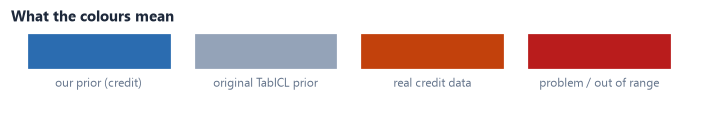

In [2]:
FIGS.save(
    style.show_palette(),
    "palette",
    caption=(
"Colour key. Grey denotes the unmodified TabICL prior, blue the credit-targeted "
"prior, orange values measured from the real datasets, and red out-of-range or "
"flagged values."
    ),
);


## 1. Load the priors and the real data


In [3]:
variants = pp.discover_pools(TASK)
print("pools found:", ", ".join(variants) if variants else "none - will generate live")
loaded, SOURCE = pp.load_variants_or_generate(TASK, n=N, seed=0, config=CONFIG)
print("source =", SOURCE)
print({k: len(v) for k, v in loaded.items()})

FOCUS = FOCUS or next((k for k in loaded if not k.startswith("original")), list(loaded)[0])
print("FOCUS (detail plots) =", FOCUS)

# The real datasets, for every comparison below. Without them the figures describe the prior in
# isolation, which is the thing that made the old notebook uninformative.
REAL = summaries.load_real_datasets(TASK)
print(f"real {TASK.upper()} datasets loaded: {len(REAL)}")
REFERENCE = pp.real_reference(TASK)


pools found: none - will generate live
no pools found for pd — generating 500 datasets per arm live from config/Exp1_PD.yaml
source = live
{'original (live)': 500, 'credit (live)': 500}
FOCUS (detail plots) = credit (live)
real PD datasets loaded: 14
reference: measured from 14 real PD datasets


## 2. Summary table

Shapes, target statistics and how each prior compares numerically.


In [4]:
pp.variant_summary(loaded, TASK)


,variant,n_sampled,rows_median,features_median,base rate mean,base rate p10,base rate p90,below 5%
0,original (live),500,782,25,0.5114,0.2091,0.8157,0.01
1,credit (live),500,776,35,0.1863,0.0798,0.2926,0.03


## 3. Which prior looks most like real credit data?

**The figure to read first.** For each prior, how far its target distribution sits from
each real PD dataset's, as a total-variation distance. Lower is better.

A distance rather than side-by-side histograms because 32 priors cannot be compared by
eye. The spread of the dots matters as much as the mean: a prior that matches one
dataset and misses the rest is not a good prior.


**How to read it.** One row per prior, best at the top. Grey dots are the individual real datasets and the blue diamond their mean, so a wide spread means the prior matches some datasets and misses others — worse than a slightly larger mean with dots close together.

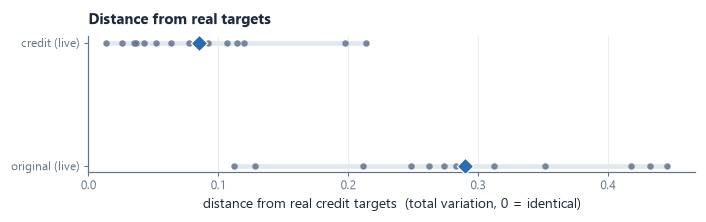

In [5]:
FIGS.save(
    e1.plot_prior_realism_ranking(loaded, REAL, task=TASK),
    "prior_realism_ranking",
    caption=(
"Distance between each prior variant's pooled target distribution and each real PD "
"dataset's, as total variation over 40 fixed bins. Diamonds give the mean across "
"datasets, dots one per dataset. Variants ordered by mean distance."
    ),
);


## 4. Do defaults cluster, as real ones do?

**The PD figure that matters.** Real credit's defining feature is that defaults
arrive in *waves*: a downturn lifts everyone's risk at once, so the default rate
varies between cohorts far more than independent coin flips would.

An i.i.d. prior cannot produce that. Our Vasicek one-factor mechanism exists
precisely to, with asset correlations taken from Basel IRB.

The dashed line is what the spread would be from chance alone, so "above 1" means
genuine clustering rather than noise. This replaces the PD target histogram, which
was a bar at 0 and a bar at 1.


**How to read it.** Left: how much the default rate varies between cohorts, divided by what pure chance would give. Above 1 means defaults genuinely arrive in waves. Right: one dataset per prior — a flat line is independent rows, a jagged one is shared shocks.

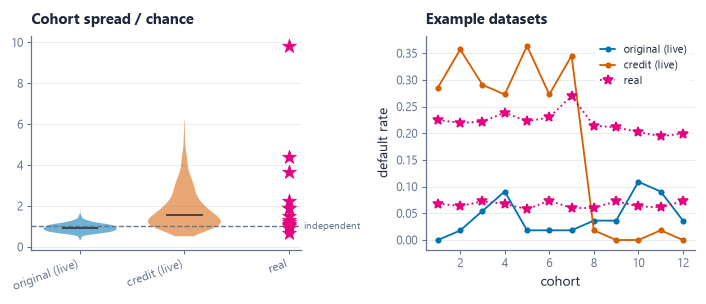

In [6]:
FIGS.save(
        e1.plot_default_clustering(loaded, REAL),
        "default_clustering",
        caption=(
"Left: distribution across synthetic datasets of the between-cohort standard "
"deviation of the default rate, divided by the binomial standard error expected under "
"independence; one violin per prior variant, stars for the real datasets, dashed line "
"at the independence reference. Right: default rate per cohort for one dataset per "
"variant and two real datasets. Cohorts are twelve contiguous blocks of rows."
        ),
    );


## 5. Base rate by prior

The right way to summarise a binary target: the *rate*, not a histogram of zeros and
ones. Dotted lines mark the real datasets, which run from 6.7% to 40%.


**How to read it.** The dashed line is a 50/50 split. The magenta ticks along the bottom are the real datasets' rates; a prior lands well if its histogram overlaps them.

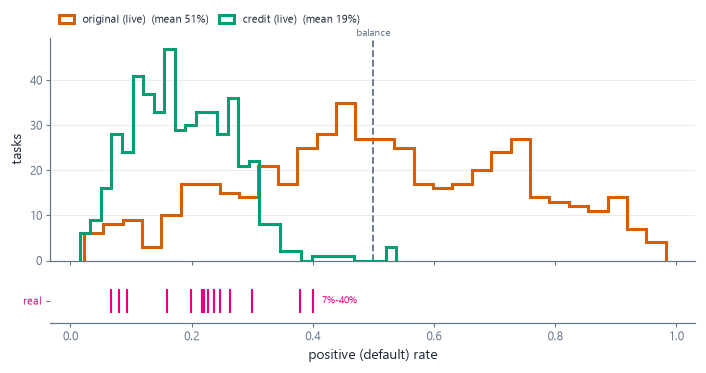

In [7]:
FIGS.save(
        pp.plot_target_comparison(loaded, TASK, reference=REFERENCE),
        "base_rate_by_variant",
        caption=(
"Distribution of the positive-class rate per synthetic dataset, one step histogram "
"per prior variant, 30 bins. The dashed vertical line marks a 50% rate; dotted lines "
"mark rates measured from the real datasets. Legend gives the mean per variant."
        ),
    );


## 6. Is the synthetic task the right difficulty?

Invisible in every other figure, and it decides whether the prior teaches anything. A
prior whose tasks are trivially easy teaches the model that features determine the
target exactly; one whose tasks are noise teaches it to predict the mean. Real credit
data is neither — **low signal but not zero** — and the shaded band is that target.

Measured with a small ExtraTrees, the same family TabICL uses for its own
predictability filter.


**How to read it.** The shaded band is where real credit data sits. A prior far above it is too easy and teaches the model that features determine the target almost exactly; far below is noise.

real-data difficulty: {'gmsc': 0.856, 'taiwan_creditcard': 0.771, 'vehicle_loan': 0.587, 'lendingclub': 0.636, 'myhom': 0.58, 'hackerearth': 0.734, 'cobranded': 0.802, 'german': 0.806, 'bank_status': 0.719, 'thomas': 0.639, 'loan_default': 0.661, 'home_credit': 0.696, 'hmeq': 0.899, 'algorithmwatch': 0.642}


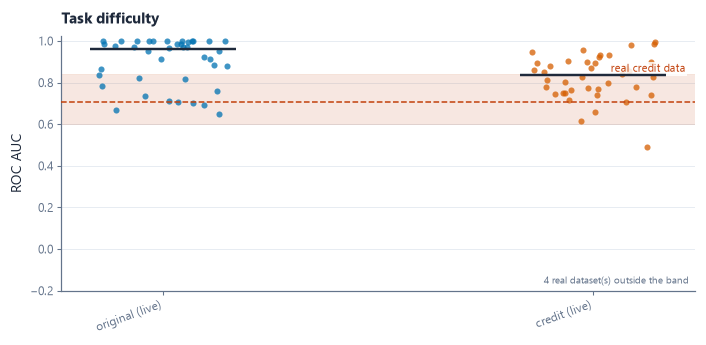

In [8]:
REAL_SCORES = summaries.real_difficulty(TASK, REAL)
print("real-data difficulty:", {k: round(v, 3) for k, v in REAL_SCORES.items()})

FIGS.save(
    e1.plot_difficulty_calibration(loaded, REAL_SCORES, task=TASK),
    "difficulty_calibration",
    caption=(
"Predictability of each synthetic dataset under a small ExtraTrees on a 70/30 split, "
"one point per dataset and one column per prior variant, with the median marked. The "
"shaded band spans the same measurement on the real credit datasets."
    ),
);


## 7. What does the model actually see?

Every figure above is a summary statistic. This is the thing itself: one synthetic table
and one real table, same layout, a few rows each. If they obviously differ, no distance
metric rescues the prior; if they do not, a reader believes the rest more readily.


**How to read it.** Shade is the value's rank within its own column, so compare *texture* — how much variation, how many repeats — not individual cells.

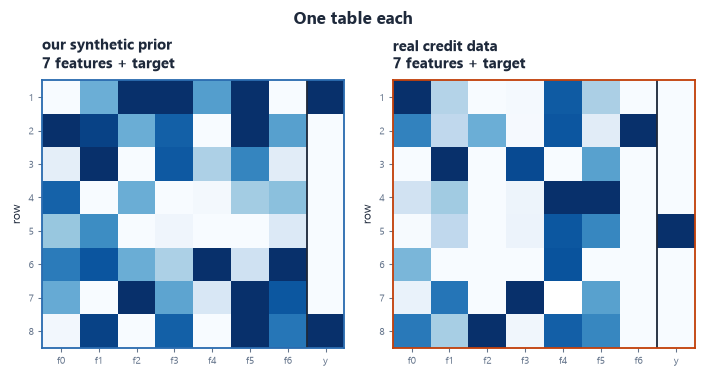

In [9]:
_real_one = next(iter(REAL.values())) if REAL else None
FIGS.save(
    e1.plot_side_by_side_tables(loaded[FOCUS][0], _real_one, task=TASK),
    "side_by_side_tables",
    caption=(
"Eight rows of one synthetic dataset and one real credit dataset, shown as heatmaps "
"with the target as the final column separated by a vertical rule. Each feature is "
"rank-normalised within its own column, so shade encodes relative value rather than "
"units."
    ),
);


## 8. Feature dependence structure

O'Prior's central measurement: the eigenvalue spectrum of the feature correlation
matrix. Two priors whose spectra coincide teach a similar dependence structure however
different their targets look — so this is the check that our changes are not *only*
about the target.


**How to read it.** Two priors whose curves coincide teach a similar feature-dependence structure, however different their targets look.

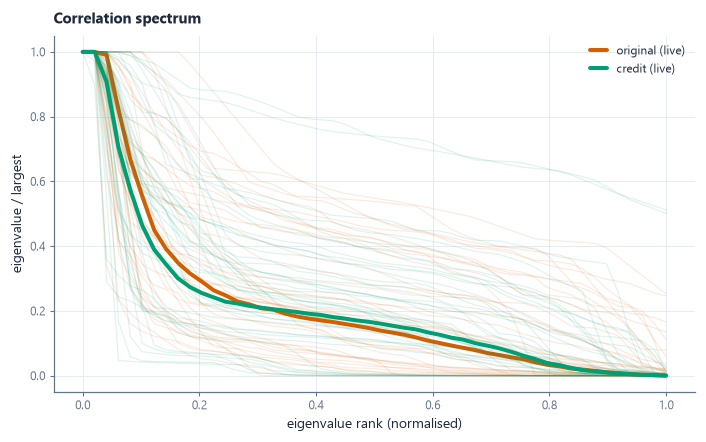

In [10]:
FIGS.save(
    pp.plot_spectrum_by_variant(loaded),
    "spectrum_by_variant",
    caption=(
"Eigenvalue spectra of the feature correlation matrix for up to 40 synthetic datasets "
"per prior variant, normalised by the largest eigenvalue and plotted against "
"normalised eigenvalue rank. Faint lines are individual datasets; bold lines are the "
"per-variant median."
    ),
);


## 9. Shape sanity check

Rows and features per synthetic dataset, against the real datasets. Cheap, and it
catches a misconfigured prior immediately.


**How to read it.** These should MATCH across priors. A difference here is a confound, not a finding.

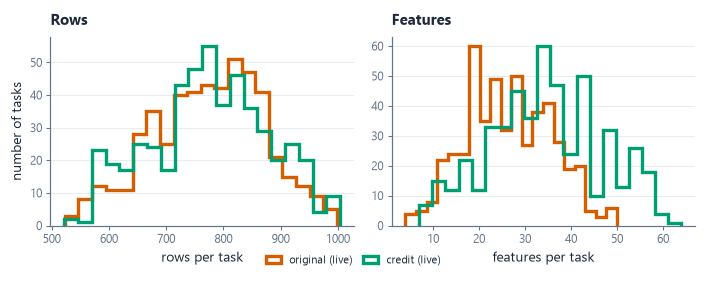

In [11]:
FIGS.save(
    pp.plot_shapes_by_variant(loaded),
    "shapes_by_variant",
    caption=(
"Left: distribution of rows per synthetic dataset. Right: distribution of features "
"per synthetic dataset. One step histogram per prior variant, 20 bins."
    ),
);


---

## Summary

Everything above, as text. This is what `output/All_Results.md` collects.


In [12]:
print(summaries.prior_summary(loaded, TASK, source=SOURCE, reference=REFERENCE))
print()
print(summaries.realism_summary(loaded, REAL, TASK))
print()
print(FIGS.summary())



PRIOR SUMMARY — PD
data source      : live  ('pool' = the files training reads; 'live' = generated on the fly now)
variants compared: original (live), credit (live)
datasets sampled : original (live)=500, credit (live)=500

--- PER VARIANT --------------------------------------------------------------

original (live):
  shape          rows 523 to 998 (median 782) | features 4 to 50 (median 25.5)
  base rate      2.2% to 98.3% (median 50.1%)
  below 5%       1.0% of datasets
  below 10%      3.4% of datasets

credit (live):
  shape          rows 522 to 1004 (median 776) | features 7 to 64 (median 35)
  base rate      1.5% to 53.8% (median 17.7%)
  below 5%       3.0% of datasets
  below 10%      15.6% of datasets

--- AGAINST THE REAL DATASETS ------------------------------------------------
real base rate: algorithmwatch=37.8%, bank_status=22.6%, cobranded=24.6%, german=30.0%, gmsc=6.7%, hackerearth=23.6%, hmeq=19.9%, home_credit=8.1%, lendingclub=16.0%, loan_default=9.3%, myhom=40.0